# Assignment 3

Deadline: 22.04.2026 12:00 CET

<Add your name, student-id and emal address>

## Prerequisites: Library imports, data load and initialization of the backtest service

In [20]:
# Standard library imports
import os
import sys
import copy
from typing import Optional

# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
src_path = os.path.join(project_root, 'qpmwp-course/src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    # load_pickle,
    load_data_spi,
)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization_data import OptimizationData
from optimization.optimization import (
    Optimization,
    Objective,
    MeanVariance,
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest



In [21]:
PATH_TO_DATA = '/Users/nawangpegentsang/Desktop/qpmwp-course/data/' # <CHANGE THIS TO YOUR PATH TO DATA>

In [22]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}jkp_data.parquet')


# -------------------------
# First, ensure that market data and jkp data 
# have the same dates by forward filling the market data for the missing dates.
# -------------------------

market_data_dates = (
    market_data
    .index.get_level_values('date')
    .unique().sort_values()
)
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)

# Find the jkp_data_dates which are not in the market_data_dates
missing_dates = jkp_data_dates[~jkp_data_dates.isin(market_data_dates)]

# Extend the market data for the missing dates using the last available market data (i.e., forward fill).
tmp_dict = {}
for date in missing_dates:
    last_date = market_data_dates[market_data_dates <= date][-1]
    tmp_dict[date] = market_data.loc[last_date]
    
df_missing = pd.concat(tmp_dict, axis=0)
df_missing.index.names = market_data.index.names
market_data_ffill = pd.concat([market_data, df_missing]).sort_index()


# -------------------------
# Define rebalancing dates
# -------------------------

n_month = 3 # We want to rebalance every n_month months

# We want to use the dates from the jkp data for rebalancing, 
# since they are less frequent than the market data dates.
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data_dates[0]
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
# Drop the first rebalancing dates which are before 2002-01-01, 
# because of poor data coverage.
rebdates = [date for date in rebdates if date > '2002-01-01']


# -------------------------
# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
# -------------------------

data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = load_data_spi(path='../data/')

In [23]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365 * 3,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365 * 3,
        min_volume=500_000,
        agg_fn=np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [24]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            **kwargs,
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        # Estimate covariance matrix and expected returns and store them
        # so that solve() can access them across iterations
        self._covmat = self.covariance.estimate(X=X, inplace=False)
        self._mu = self.expected_return.estimate(X=X, inplace=False)

        # Initialize the objective with risk_aversion = 1 as a starting point
        risk_aversion = self.params.get('risk_aversion', 1.0)
        self.objective = Objective(
            q=self._mu * -1,
            P=self._covmat * 2 * risk_aversion,
        )

    def solve(self) -> None:
        max_iter = self.params.get('max_iter', 10)
        tol = self.params.get('tol', 1e-8)

        # Starting risk aversion (set in set_objective or passed as param)
        risk_aversion = self.params.get('risk_aversion', 1.0)
        Sigma = self._covmat.to_numpy()

        for _ in range(max_iter):
            # Update the quadratic objective with the current risk aversion
            self.objective = Objective(
                q=self._mu * -1,
                P=self._covmat * 2 * risk_aversion,
            )
            # Call the parent QP solver
            super().solve()
            # Retrieve solution weights as a numpy vector
            w = np.array(list(self.results['weights'].values()))
            # Portfolio variance  w' Sigma w
            port_var = float(w @ Sigma @ w)

            if port_var < tol:
                # Degenerate solution – stop early to avoid division by zero
                break

            # Update risk aversion: lambda_{t+1} = 1 / sigma_p^2
            new_risk_aversion = 1.0 / port_var

            # Convergence check
            if abs(new_risk_aversion - risk_aversion) < tol:
                break

            risk_aversion = new_risk_aversion

        return None
    

b) 

(2 points)

Provide either a theoretical or an empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

### Why the algorithm converges to the MSR portfolio

The MSR portfolio maximizes return per unit of risk, but solving this directly is difficult. Instead, we approximate it by repeatedly solving a mean-variance optimization problem.

The key idea is that at the optimal MSR portfolio, the risk-aversion parameter satisfies:

$$
\lambda = \frac{1}{w^\top \Sigma w}.
$$

The algorithm works as follows:
1. Start with an initial value of $\lambda$.
2. Solve the mean-variance problem to obtain portfolio weights $w$.
3. Compute the portfolio variance $w^\top \Sigma w$.
4. Update $\lambda = 1 / (w^\top \Sigma w)$.
5. Repeat the process.

With each iteration, the balance between risk and return is adjusted. The weights and $\lambda$ quickly stabilize, meaning the solution satisfies the MSR condition.

**Intuition:** The algorithm works because it keeps updating risk aversion until it matches the actual risk of the portfolio, which characterizes the MSR portfolio.

In [ ]:
# Empirical check: run a single-date optimization and inspect convergence
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    max_iter=10,
    tol=1e-8,
)
bs.prepare_rebalancing(rebdates[-1])
bs.optimization.set_objective(bs.optimization_data)
bs.optimization.solve()

# Inspect resulting weights
weights_ms = pd.Series(bs.optimization.results['weights'])
print('Number of non-zero weights:', (weights_ms > 1e-4).sum())
print('Sum of weights:', weights_ms.sum().round(6))
print('\nTop 10 holdings:')
print(weights_ms.sort_values(ascending=False).head(10))


Number of non-zero weights: 30
Sum of weights: 1.0

Top 10 holdings:
127    0.100000
24     0.100000
33     0.060369
256    0.050000
8      0.050000
231    0.050000
296    0.050000
213    0.050000
191    0.050000
2      0.050000
dtype: float64


## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

The code below runs a backtest of a MaxSharpe portfolio that includes a turnover penalty. The optimization problem is

$$
\arg\min_{w}\;\Bigl(-\mu^\top w \;+\; \frac{\lambda}{2}\, w^\top \Sigma w \;+\; \tau |w - w^{0}|\Bigr),
$$

where $\mu$ is the vector of expected returns, $\Sigma$ the covariance matrix, and $w^{0}$ the initial portfolio weights.
The parameter $\lambda$ is the risk‑aversion coefficient calibrated in Question 1.a, and $\tau$ is the turnover penalty parameter to be calibrated here.

Your task is to choose a value for the turnover penalty such that the MaxSharpe backtest exhibits an annual turnover of approximately 100\%.

**Hint:** run the backtest for only a few rebalancing dates, compute the resulting turnover using method `bt_ms.turnover`, and iteratively adjust the turnover penalty until the target turnover is reached.


In [ ]:
target = 100
tol = 10
penalty = 0.005   # starting value

bs.settings['rebdates'] = rebdates[-20:]

# Iteratively adjust the turnover penalty to get close to the target annual turnover of 100%
for i in range(5):
    bs.optimization = MaxSharpe(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='cvxopt',
        turnover_penalty=penalty,
    )
    bt_quick = Backtest()
    bt_quick.run(bs=bs)

    rs = bs.data.get_return_series(weekdays_only=False)
    ann_to = bt_quick.strategy.turnover(return_series=rs).mean() * (12 / n_month) * 100

    if abs(ann_to - target) <= tol:
        break
    print(f"iteration {i+1}: tau={penalty:.4f} -> {ann_to:.1f}%")

    # adjust penalty iteratively
    if ann_to < target:
        penalty *= 0.7  # turnover too low -> reduce penalty
    else:
        penalty *= 1.3  # turnover too high -> increase penalty


Rebalancing date: 2019-04-30
Rebalancing date: 2019-07-31
Rebalancing date: 2019-10-31
Rebalancing date: 2020-01-31
Rebalancing date: 2020-04-30
Rebalancing date: 2020-07-31
Rebalancing date: 2020-10-31
Rebalancing date: 2021-01-31
Rebalancing date: 2021-04-30
Rebalancing date: 2021-07-31
Rebalancing date: 2021-10-31
Rebalancing date: 2022-01-31
Rebalancing date: 2022-04-30
Rebalancing date: 2022-07-31
Rebalancing date: 2022-10-31
Rebalancing date: 2023-01-31
Rebalancing date: 2023-04-30
Rebalancing date: 2023-07-31
Rebalancing date: 2023-10-31
Rebalancing date: 2024-01-31
iteration 1: tau=0.0050 -> 81.7%
Rebalancing date: 2019-04-30
Rebalancing date: 2019-07-31
Rebalancing date: 2019-10-31
Rebalancing date: 2020-01-31
Rebalancing date: 2020-04-30
Rebalancing date: 2020-07-31
Rebalancing date: 2020-10-31
Rebalancing date: 2021-01-31
Rebalancing date: 2021-04-30
Rebalancing date: 2021-07-31
Rebalancing date: 2021-10-31
Rebalancing date: 2022-01-31
Rebalancing date: 2022-04-30
Rebalancin

In [ ]:
# Set the final penalty and rebalancing dates for the full backtest
bs.settings['rebdates'] = rebdates

# Full backtest with calibrated penalty
bt_ms = Backtest()
bt_ms.run(bs=bs)

return_series_check = bs.data.get_return_series(weekdays_only=False)
ann_to_check = bt_ms.strategy.turnover(return_series=return_series_check).mean() * (12 / n_month) * 100
print(f'Full backtest — annualised turnover with tau={penalty}: {ann_to_check:.1f}%')
print('(Target: ~100%)')

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

## 4. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% per annum (p.a.) and variable costs of 0.3% p.a.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


/Users/nawangpegentsang/Desktop/qpmwp-course/src/backtesting/strategy.py:195: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  portf_ret[0] -= varcost[0]
/Users/nawangpegentsang/Desktop/qpmwp-course/src/backtesting/strategy.py:195: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  portf_ret[0] -= varcost[0]


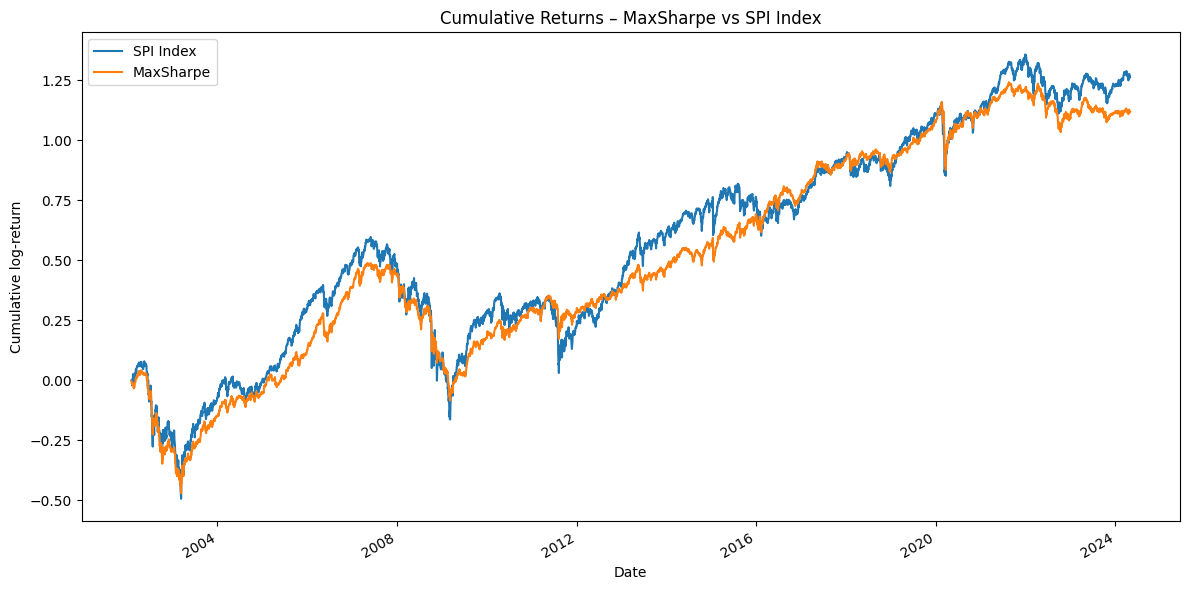

In [8]:
import matplotlib.pyplot as plt

fixed_costs    = 0.01   # 1% p.a.
variable_costs = 0.003  # 0.3% p.a.
return_series = bs.data.get_return_series(weekdays_only=False)

sim_ms = bt_ms.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

sim = pd.concat({
    'bm': bs.data.bm_series,
    'ms': sim_ms,
}, axis = 1).dropna()

sim.columns = ['SPI Index', 'MaxSharpe']

# Plot the cumulative returns of the strategy and the benchmark
np.log(1 + sim).cumsum().plot(
    title='Cumulative Returns – MaxSharpe vs SPI Index',
    figsize=(12, 6),
    ylabel='Cumulative log-return',
    xlabel='Date',
)
plt.tight_layout()
plt.show()


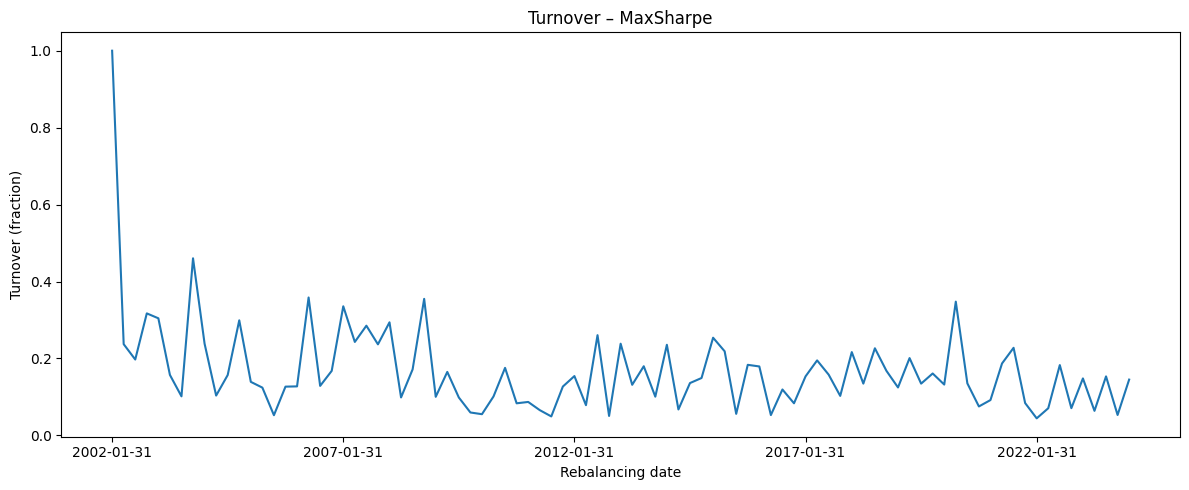

In [10]:
# Turnover
to_ms = bt_ms.strategy.turnover(return_series=return_series)
to_ms.plot(
    title='Turnover – MaxSharpe',
    figsize=(12, 5),
    ylabel='Turnover (fraction)',
    xlabel='Rebalancing date',
)
plt.tight_layout()
plt.show()

In [11]:
# Annualized turnover per annum (pa) in percentage
rebalancings_per_year = 12 / n_month   # = 4

to_pa = round(to_ms.mean() * rebalancings_per_year * 100, 2)
print(f"The annualized turnover is: {to_pa}%")

The annualized turnover is: 67.89%


In [16]:
# Decriptive statistics
import empyrical as ep

annual_return     = {}
cumulative_return = {}
annual_volatility = {}
sharpe_ratio      = {}
max_drawdown      = {}
tracking_error    = {}

for col in sim.columns:
    annual_return[col]     = ep.annual_return(sim[col])
    cumulative_return[col] = ep.cum_returns(sim[col]).iloc[-1]
    annual_volatility[col] = ep.annual_volatility(sim[col])
    sharpe_ratio[col]      = ep.sharpe_ratio(sim[col])
    max_drawdown[col]      = ep.max_drawdown(sim[col])
    tracking_error[col]    = ep.annual_volatility(sim[col] - sim['SPI Index'])

stats = pd.concat([
    pd.DataFrame(annual_return,     index=['Annual Return']),
    pd.DataFrame(cumulative_return, index=['Cumulative Return']),
    pd.DataFrame(annual_volatility, index=['Annual Volatility']),
    pd.DataFrame(sharpe_ratio,      index=['Sharpe Ratio']),
    pd.DataFrame(max_drawdown,      index=['Max Drawdown']),
    pd.DataFrame(tracking_error,    index=['Tracking Error vs SPI']),
])

print(stats)


                       SPI Index  MaxSharpe
Annual Return           0.055644   0.049179
Cumulative Return       2.532512   2.061326
Annual Volatility       0.164658   0.105783
Sharpe Ratio            0.411353   0.506931
Max Drawdown           -0.532487  -0.435990
Tracking Error vs SPI   0.000000   0.092389
